# Plot of Electronegativity

We can visualize the nature of covalent, plar covalent and ionic bonds. Electrobegativity can be scored many ways. the data set that I used has values dveloped by Pauling and by Allen. They are based on different ways of measuring electron affinity.

Paulings values are deribed from differences in bond strengths between homodiatomic dissociation energies and the dissociation energy of the bond between the elements in question. e.g. Comparing the dissociation energies for H<sub>2</sub>, Br<sub>2</sub>, and HBr. As a result some elements that do not form bonds with other elements, like helium and neon, do noy have values in this system.

Allens values are absed on the energy required to eject an electron from the outer valence shell of the element. It correlates strongly to Pauling's values. The noble gasses have the highest electronegativity in this system because they have a perfect outer shell that resists disruption.




## Where Did That Data Come From

The data was from tables collected in the [Electronegativity Data page on Wikipedia](https://en.wikipedia.org/wiki/Electronegativities_of_the_elements_(data_page)). References for the original sources can be found there.

I copies the data and editted them into a csv text file as [Electroneg-wikipedia.csv](Electroneg-wikipedia.csv).

## The Plot



In [1]:
import pandas as pd
import numpy as np

# load the data
df = pd.read_csv("Electroneg-wikipedia.csv", comment="#", skipinitialspace=True)

# clean the data
#df.drop(columns=["Goldschmidt"], inplace=True) # Drop the "Goldschmidt" column, which is not needed.
#df.drop(columns=["extraction (tonnes/yr)"], inplace=True) # This column is not needed for our analysis.

#df.sort_values(by="number", inplace=True, ascending=True)  # Sort the DataFrame by the atomic number column in ascending order.

# print all rows in dataframe
# pd.set_option('display.max_rows', None)  # Set the option to display all rows in the DataFrame.

display(df.head(3))

# df.dtypes # Check the data types of each column in the DataFrame. This will help us understand if any number columns were imported as strings.

,number,symbol,name,pauling,allen
0,1,H,hydrogen,2.20,2.300
1,2,He,helium,NaN,4.160
2,3,Li,lithium,0.98,0.912


### A Visual Check

A quick and easy way to see how two data sets compare is to graph one against the other. Here we will plot the two sets of abundance values. If they are both the same for each element we shpuld get a stricght line.

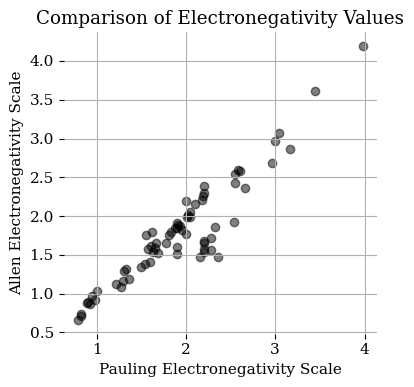

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
plt.scatter(df["pauling"], df["allen"], alpha=0.5)
plt.xlabel("Pauling Electronegativity Scale")
plt.ylabel("Allen Electronegativity Scale")
plt.title("Comparison of Electronegativity Values")
plt.grid(True)
plt.show()

In [ ]:
import plotly.express as px
#import kaleido

fig = px.scatter(df, 
                x="pauling", 
                y="allen",
                width=500, 
                height=500, 
                hover_data=["symbol", "name"], 
                log_y=False, 
                title="Electronegativity", 
                labels={"number": "Atomic Number", "name": "Element Name"},
                template="simple_white",
)


fig.update_traces(
    customdata=df[["name"]],
    hovertemplate=
    "Pauling #: %{x}<br>" +
    "Allen: %{y}<br>" +
    "Element: %{customdata[0]}<extra></extra>"
)

fig.update_traces(
#    mode="lines+markers",
    mode="markers",
    marker=dict(size=5, color="black", opacity=1,),
#    line=dict(color="black", width=2),
    line=None,  # Remove the line connecting the markers
    selector=dict(mode="markers")
)



# Make the plot above again using tufte style
fig.update_layout(
    font=dict(
        family="Palatino, Garamond, Computer Modern, Times New Roman",     # e.g. "Times New Roman", "Helvetica", "Computer Modern"
        size=16,
        color="black"
    ),
    title = None,
    title_font_size=14,
    xaxis_title="Pauling Electronegativity",
    yaxis_title="Allen Electronegativity",
    xaxis_title_font_size=16,
    yaxis_title_font_size=16,
    xaxis=dict(
        showline=False,
        linewidth=1,
        linecolor='black',
        ticks='outside',
        tickwidth=1,
        tickcolor='black',
        ticklen=5,
        range=[0, 5]
    ),
    yaxis=dict(
        showline=False,
        linewidth=1,
        linecolor='black',
        ticks='outside',
        tickwidth=1,
        tickcolor='black',
        ticklen=5,
        range=[0, 5],
    )
)


fig.write_html("plot_electronegativity_plotly_tufte.html", include_plotlyjs="cdn")
#fig.write_image("plot_electronegativity_plotly_tufte.pdf") # requires kaleido package to be installed
fig.show()

```{raw} html
:file: plot_abundance_plotly_tufte.html
```


[Click here to See Interactive Plot](plot_abundance_plotly_tufte.html) (just in case it doesn't appear on this page).

This plot has the crisp and uncluttered style that I prefer. It's interactive too. Mouseover to query each point.

## The Plot for the Textbook

The code below will produce the plot that is used in the textbook


### the Final Plot

I am more experienced with *MatPlotLib* than *Plotly* and will make my final plot using that library.

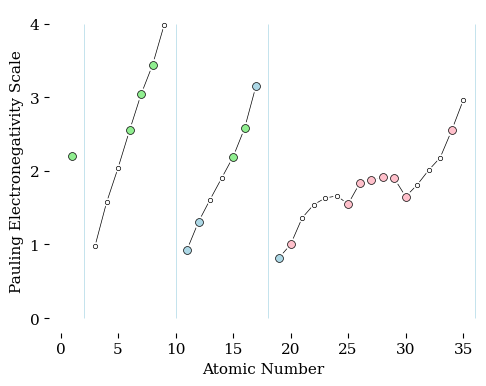

<Figure size 500x400 with 0 Axes>

In [16]:
import matplotlib.pyplot as plt

styles_location = "../../../styles/"
plt.rcParamsDefault
plt.style.use(styles_location + "tufte.mplstyle")        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  

size = 10
color = 'black'
plt.figure(figsize=(5, 4))

# List of elements to plot. excludes noble gases and unstable radioactive elements.
#group_list = [[1,1], [3,9], [11,17], [19,35], [37,42], [44,53], [55,60], [62,83], ] 
group_list = [[1,1], [3,9], [11,17], [19,35], ] 

for group in group_list:
    group = list(range(group[0], group[1] + 1)) # Create a list of atomic numbers from bounds (inclusive) 
    # choose x values where atomic number is in group list and y values where atomic number is in group list
    x = df[df["number"].isin(group)]["number"]
    y = df[df["number"].isin(group)]["pauling"] 
    ax.scatter(x, y, 
           marker = "o", s=size, 
           color="white", edgecolor = "black",
           linewidth = 0.5, zorder=3)
    ax.scatter(x, y, 
           marker = "o", s=size+20, 
           color="white", edgecolor = "white",
           linewidth = 0.5, zorder=2)
    ax.plot(x, y, color="black", linewidth=0.5, zorder=1) # Add a line connecting the points in the scatter plot to better visualize the trend in the data.

highlightsize = 32
group = [1,6,7,8,15,16] # Create a list of atomic numbers from bounds (inclusive) 
x = df[df["number"].isin(group)]["number"]
y = df[df["number"].isin(group)]["pauling"] 
ax.scatter(x, y, 
       marker = "o", s=highlightsize+40, 
       color="white", edgecolor = "white",
       linewidth = 0.5, zorder=2)
ax.scatter(x, y, 
       marker = "o", s=highlightsize, 
       color="lightgreen", edgecolor = "black",
       linewidth = 0.5, zorder=3)

#group = [20, 25, 26, 27, 28, 29 ,30, 34, 42, ] # Create a list of atomic numbers from bounds (inclusive) 
group = [20, 25, 26, 27, 28, 29 ,30, 34, ] # Create a list of atomic numbers from bounds (inclusive) 
x = df[df["number"].isin(group)]["number"]
y = df[df["number"].isin(group)]["pauling"] 
ax.scatter(x, y, 
       marker = "o", s=highlightsize+40, 
       color="white", edgecolor = "white",
       linewidth = 0.5, zorder=2)
ax.scatter(x, y, 
       marker = "o", s=highlightsize, 
       color="pink", edgecolor = "black",
       linewidth = 0.5, zorder=3)

group = [11,12,19,17] # Create a list of atomic numbers from bounds (inclusive) 
x = df[df["number"].isin(group)]["number"]
y = df[df["number"].isin(group)]["pauling"] 
ax.scatter(x, y, 
       marker = "o", s=highlightsize+40, 
       color="white", edgecolor = "white",
       linewidth = 0.5, zorder=2)
ax.scatter(x, y, 
       marker = "o", s=highlightsize, 
       color="lightblue", edgecolor = "black",
       linewidth = 0.5, zorder=3)




ax.set(ylabel="Pauling Electronegativity Scale", 
       xlabel="Atomic Number",
       yscale="linear",
       yticks=[ 0,1,2,3,4],
       xscale="linear",
       xlim=[-1,36.2],                  
       ylim=[-0.2,4.2],   
      )
#ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   
ax.minorticks_off()

ax.vlines(x=[2,10,18,36], ymin= 0.0, ymax=4.0,
          color="lightblue", linewidth=0.5, zorder=1)
fig.savefig("plot.pdf")
plt.show()

This image was exported as a PDF and edited using Affinity Publisher to add element labels.